In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [2]:
#Prunable Linear Layer
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()

        # Standard parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # Convert gate_scores → gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # Apply pruning
        pruned_weights = self.weight * gates

        # Linear operation
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [3]:
#nn
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates.append(module.get_gates().view(-1))
        return torch.cat(gates)

In [4]:
#data loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 75.8MB/s]


In [6]:
#Sparsity Loss Function
def compute_sparsity_loss(model):
    gates = model.get_all_gates()
    return torch.sum(gates)

In [7]:
#training
def train_model(lambda_val, epochs=10):
    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            cls_loss = criterion(outputs, labels)
            sparsity_loss = compute_sparsity_loss(model)

            loss = cls_loss + lambda_val * sparsity_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Lambda {lambda_val} | Epoch {epoch+1} | Loss: {total_loss:.2f}")

    return model

In [8]:
#evaluation
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def compute_sparsity(model, threshold=1e-2):
    gates = model.get_all_gates().detach().cpu().numpy()
    pruned = np.sum(gates < threshold)
    total = len(gates)
    return 100 * pruned / total

In [9]:
#training
lambdas = [1e-5, 1e-4, 1e-3]
results = []

best_model = None
best_acc = 0

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam, epochs=5)

    acc = evaluate(model)
    sparsity = compute_sparsity(model)

    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity))

    if acc > best_acc:
        best_acc = acc
        best_model = model


Training with lambda = 1e-05
Lambda 1e-05 | Epoch 1 | Loss: 3755.62
Lambda 1e-05 | Epoch 2 | Loss: 3197.99
Lambda 1e-05 | Epoch 3 | Loss: 2766.32
Lambda 1e-05 | Epoch 4 | Loss: 2420.36
Lambda 1e-05 | Epoch 5 | Loss: 2143.95
Lambda: 1e-05 | Accuracy: 55.03% | Sparsity: 0.04%

Training with lambda = 0.0001
Lambda 0.0001 | Epoch 1 | Loss: 31346.99
Lambda 0.0001 | Epoch 2 | Loss: 26061.26
Lambda 0.0001 | Epoch 3 | Loss: 21259.88
Lambda 0.0001 | Epoch 4 | Loss: 17112.77
Lambda 0.0001 | Epoch 5 | Loss: 13709.13
Lambda: 0.0001 | Accuracy: 54.39% | Sparsity: 0.08%

Training with lambda = 0.001
Lambda 0.001 | Epoch 1 | Loss: 307419.59
Lambda 0.001 | Epoch 2 | Loss: 255074.88
Lambda 0.001 | Epoch 3 | Loss: 206852.25
Lambda 0.001 | Epoch 4 | Loss: 164814.58
Lambda 0.001 | Epoch 5 | Loss: 130032.93
Lambda: 0.001 | Accuracy: 53.20% | Sparsity: 0.08%


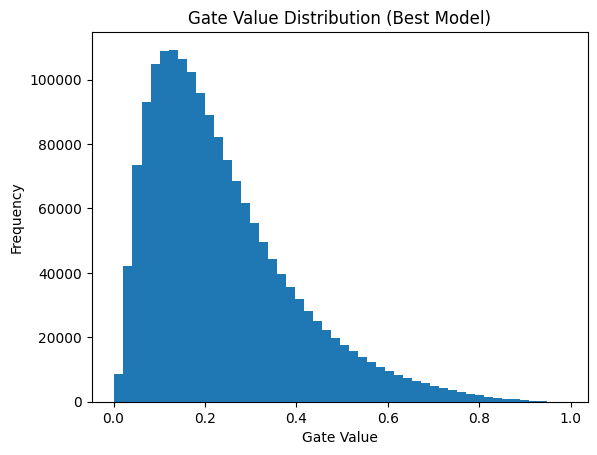

In [10]:
gates = best_model.get_all_gates().detach().cpu().numpy()

plt.hist(gates, bins=50)
plt.title("Gate Value Distribution (Best Model)")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()